# Categorical Feature Engineering & Exploration

## Objective
This notebook explores four key categorical formulation features: `helper_lipid`, `sterol_lipid`, `peg_lipid`, and `target_type`. The goal is to analyze their distributions, handle missing values, and group rare categories to prevent model overfitting.

## Strategy
1. **Assess Missingness & Cardinality:** Identify how much data is missing and how many unique values exist per feature.
2. **Visual Exploration:** Plot the frequencies of the top categories.
3. **Thresholding (Rare Category Grouping):** Consolidate low-frequency categorical values into an "Other" bucket.
4. **Encoding & Export:** One-hot encode the refined features and export the final dataset for Model 3 evaluation.


## Data Loading

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load the cleaned full dataset
df_model = pd.read_csv("../data/processed/df_model.csv")
df_model.info()


<class 'pandas.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 37 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   lnp_id                                582 non-null    int64  
 1   ionizable_lipid                       582 non-null    str    
 2   peg_lipid                             582 non-null    str    
 3   sterol_lipid                          582 non-null    str    
 4   helper_lipid                          582 non-null    str    
 5   lipid_molar_ratio                     582 non-null    str    
 6   particle_size_nm_std                  582 non-null    str    
 7   pdi_std                               448 non-null    str    
 8   zeta_potential_mv_std                 223 non-null    str    
 9   encapsulation_efficiency_percent_std  582 non-null    str    
 10  loading_capacity_std                  555 non-null    str    
 11  target_type                   

After data cleaning (see notebook_01) of the target variable ["encapsulation_efficiency"] and the numerical features ["ionizable_ratio", "helper_ratio", "sterol_ratio", "peg_ratio", "particle_size_nm"] 582 entries remained.

## Categorical Feature: Ionizable Lipid

In notebook_01 the categorical feature "ionizable_lipid" was explored and lipids appearing less than 5 times were grouped as "Other" (see the column "ionizable_lipid_grouped").

In [43]:
df_model["ionizable_lipid_grouped"].value_counts()

ionizable_lipid_grouped
Custom lipid     253
C12-200           61
DLin-MC3-DMA      54
DLin-KC2-DMA      54
A2-Iso5-2DC18     34
OF-02             24
Other             24
ALC-0315          14
4A3-SC8           13
AX4               10
L202               9
SM-102             7
DLinDMA            7
DOTAP              6
DOTMA              6
DODAP              6
Name: count, dtype: int64

Apply **One-hot encoding** to convert 'ionizable_lipid_grouped' into machine-readable binary columns (0 or 1) and attach these new features directly to the main DataFrame.

**Machine Learning Rationale:**
Standard regression and tree-based algorithms cannot perform mathematical operations on text strings. By creating "dummy" variables, each lipid category becomes its own independent feature. Concatenating them immediately allows the DataFrame to act as a central repository, making the final feature selection step straightforward.

In [44]:
ionizable_dummies = pd.get_dummies(
    df_model["ionizable_lipid_grouped"],
    prefix="ionizable", 
    dtype=int
)

In [45]:
df_model = pd.concat([df_model, ionizable_dummies], axis=1)

## Categorical Feature: Helper Lipid

### Helper Lipid - Exploration

In [46]:
df_model["helper_lipid"].value_counts()

helper_lipid
DOPE             300
DSPC             231
DPPC              14
DOPC              13
DSPE               4
DMPC               4
DLPE               3
BMP                2
SOPC               2
POPE               1
4ME                1
CL                 1
SOPE               1
DEPE               1
DPPE               1
C16-18:1 PE        1
POPC               1
DSPC + TMR-PC      1
Name: count, dtype: int64

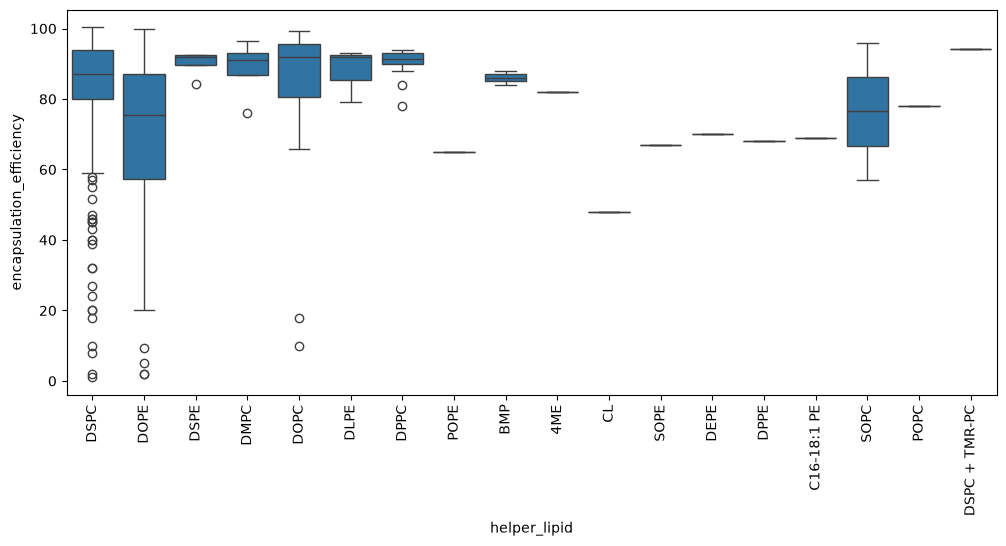

In [47]:
plt.figure(figsize=(12,5))
import seaborn as sns
sns.boxplot(
    data=df_model,
    x="helper_lipid",
    y="encapsulation_efficiency"
)
plt.xticks(rotation=90)
plt.show()

### Helper Lipid - Observations & Cleaning Strategy

**Observations**
The `helper_lipid` feature is highly concentrated among a few key molecules. `DOPE` (300 instances) and `DSPC` (231 instances) make up the vast majority of the formulations. While `DPPC` (14) and `DOPC` (13) have moderate representation, there is a "long tail" of 14 different lipids that appear fewer than 5 times each, several of which only appear a single time.

**Strategy: Thresholding Rare Categories**
To prepare this categorical feature for machine learning, any helper lipid appearing fewer than 5 times will be grouped into a single `"Other"` category. 

**Machine Learning Rationale:**
* **Preventing Overfitting:** Tree-based models (like Random Forests) can easily memorize rare instances, using a lipid that appears only once to perfectly predict the training data but failing to generalize to new data.
* **Reducing Sparsity:** One-hot encoding the raw column would add 14 nearly empty columns to the dataset, unnecessarily increasing dimensionality and diluting the predictive power of stronger features.
* **Avoiding Train/Test Mismatches:** If a lipid with only 1 instance is randomly sorted into the test set, the model will throw an error during evaluation because it never learned how to handle that feature during training.

In [48]:
# Calculate frequencies of helper_lipid
helper_counts = df_model["helper_lipid"].value_counts()

# Identify categories with fewer than 5 instances
rare_helpers = helper_counts[helper_counts < 5].index

# Create the new grouped column
df_model["helper_lipid_grouped"] = df_model["helper_lipid"].replace(rare_helpers, "Other")

# Verify the new distribution
print(df_model["helper_lipid_grouped"].value_counts())


helper_lipid_grouped
DOPE     300
DSPC     231
Other     24
DPPC      14
DOPC      13
Name: count, dtype: int64


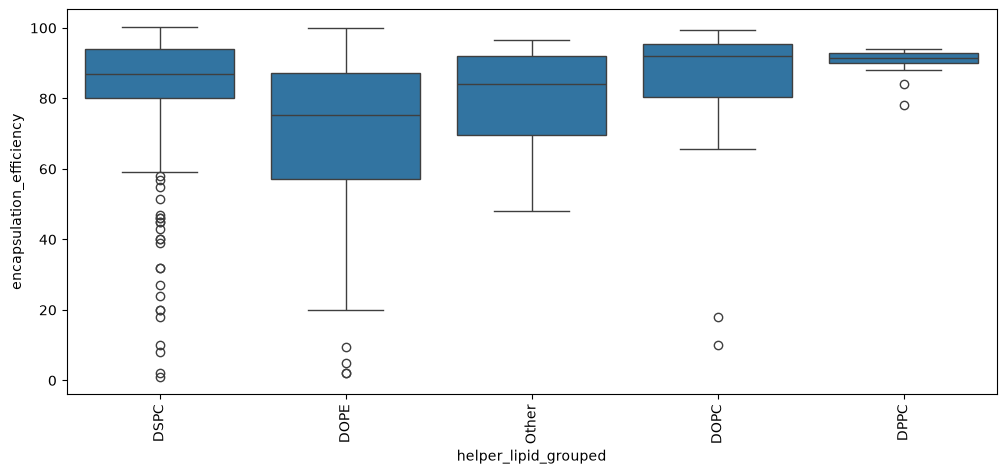

In [49]:
plt.figure(figsize=(12,5))
import seaborn as sns
sns.boxplot(
    data=df_model,
    x="helper_lipid_grouped",
    y="encapsulation_efficiency"
)
plt.xticks(rotation=90)
plt.show()

### Helper Lipid - One-Hot Encoding


In [50]:
# Create the dummy variables
helper_dummies = pd.get_dummies(
    df_model["helper_lipid_grouped"],
    prefix="helper", 
    dtype=int
)

# Attach the new dummy columns to the main dataframe
df_model = pd.concat([df_model, helper_dummies], axis=1)

# Verify the new columns were added successfully
print(df_model.columns)

Index(['lnp_id', 'ionizable_lipid', 'peg_lipid', 'sterol_lipid',
       'helper_lipid', 'lipid_molar_ratio', 'particle_size_nm_std', 'pdi_std',
       'zeta_potential_mv_std', 'encapsulation_efficiency_percent_std',
       'loading_capacity_std', 'target_type', 'nucleic_acid_sequence',
       'peg_lipid_original', 'ionizable_lipid_original',
       'helper_lipid_original', 'sterol_lipid_original',
       'ionizable_lipid_smiles', 'peg_lipid_smiles', 'sterol_lipid_smiles',
       'helper_lipid_smiles', 'synthesis_info', 'bioactivity_profile',
       'paper_title', 'paper_authors', 'paper_doi', 'paper_journal',
       'paper_year', 'encapsulation_efficiency', 'lipid_molar_ratio_clean',
       'ionizable_ratio', 'helper_ratio', 'sterol_ratio', 'peg_ratio',
       'ratio_sum', 'particle_size_nm', 'ionizable_lipid_grouped',
       'ionizable_4A3-SC8', 'ionizable_A2-Iso5-2DC18', 'ionizable_ALC-0315',
       'ionizable_AX4', 'ionizable_C12-200', 'ionizable_Custom lipid',
       'ionizable_DLi

## Categorical Feature: Sterol Lipid

### Sterol Lipid - Exploration

In [51]:
df_model["sterol_lipid"].value_counts()

sterol_lipid
cholesterol      578
¥â-sitosterol      1
fucosterol         1
campesterol        1
stigmastanol       1
Name: count, dtype: int64

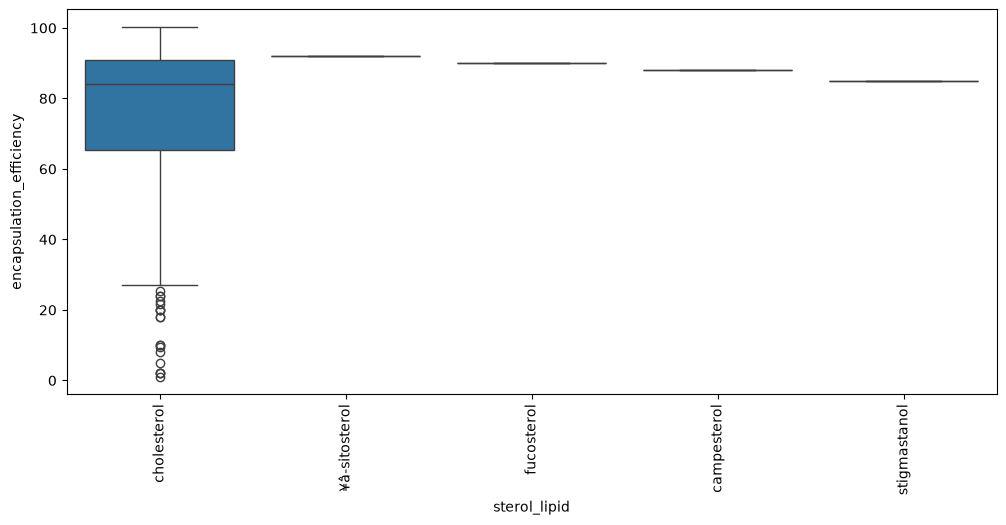

In [52]:
plt.figure(figsize=(12,5))
import seaborn as sns
sns.boxplot(
    data=df_model,
    x="sterol_lipid",
    y="encapsulation_efficiency"
)
plt.xticks(rotation=90)
plt.show()

### Sterol Lipid - Observations & Cleaning Strategy

**Observations:**
The `sterol_lipid` feature is almost entirely dominated by `cholesterol` (578 instances). Four other sterol variants appear only a single time each.

**Strategy: Binary Grouping & Encoding**
All non-cholesterol lipids will be grouped into a single `"Other"` category. 

**Machine Learning Rationale:**
With only one instance each, these rare sterols offer no generalizable pattern for the model to learn. Grouping them creates a simple, robust binary feature ("Cholesterol" vs. "Other"), which eliminates extreme sparsity and prevents the model from overfitting to single-observation outliers.

In [53]:
# Calculate frequencies of sterol_lipid
sterol_counts = df_model["sterol_lipid"].value_counts()

# Identify categories with fewer than 5 instances
rare_sterol = sterol_counts[sterol_counts < 5].index

# Create the new grouped column
df_model["sterol_lipid_grouped"] = df_model["sterol_lipid"].replace(rare_sterol, "Other")

# Verify the new distribution
print(df_model["sterol_lipid_grouped"].value_counts())


sterol_lipid_grouped
cholesterol    578
Other            4
Name: count, dtype: int64


### Sterol Lipid - One-Hot Encoding

In [54]:
# Create the dummy variables
sterol_dummies = pd.get_dummies(
    df_model["sterol_lipid_grouped"],
    prefix="sterol", 
    dtype=int
)

# Attach the new dummy columns to the main dataframe
df_model = pd.concat([df_model, sterol_dummies], axis=1)

# Verify the new columns were added successfully
print(df_model.columns)

Index(['lnp_id', 'ionizable_lipid', 'peg_lipid', 'sterol_lipid',
       'helper_lipid', 'lipid_molar_ratio', 'particle_size_nm_std', 'pdi_std',
       'zeta_potential_mv_std', 'encapsulation_efficiency_percent_std',
       'loading_capacity_std', 'target_type', 'nucleic_acid_sequence',
       'peg_lipid_original', 'ionizable_lipid_original',
       'helper_lipid_original', 'sterol_lipid_original',
       'ionizable_lipid_smiles', 'peg_lipid_smiles', 'sterol_lipid_smiles',
       'helper_lipid_smiles', 'synthesis_info', 'bioactivity_profile',
       'paper_title', 'paper_authors', 'paper_doi', 'paper_journal',
       'paper_year', 'encapsulation_efficiency', 'lipid_molar_ratio_clean',
       'ionizable_ratio', 'helper_ratio', 'sterol_ratio', 'peg_ratio',
       'ratio_sum', 'particle_size_nm', 'ionizable_lipid_grouped',
       'ionizable_4A3-SC8', 'ionizable_A2-Iso5-2DC18', 'ionizable_ALC-0315',
       'ionizable_AX4', 'ionizable_C12-200', 'ionizable_Custom lipid',
       'ionizable_DLi

# Categorical Feature: PEG Lipid

### PEG Lipid - Exploration

In [55]:
df_model["peg_lipid"].value_counts()

peg_lipid
C14-PEG2000             250
DMG-PEG2000             117
PEG-lipid                58
PEG-c-DMA                46
DMG-PEG5k                23
DMPE-PEG2000             14
C14-PEG 2000             14
C16-Ceramide-PEG2000     13
DSG-PEG2000               8
DSPE-PEG2000              7
DPPE-PEG2000              7
ALC-0159                  6
DMG                       6
C8-Ceramide-PEG2000       2
DMPE-PEG550               1
DMPE-PEG1000              1
DPPE-PEG1000              1
DSPE-PEG550               1
DSPE-PEG1000              1
DSPE-2armPEG2000          1
DOPE-PEG550               1
DOPE-PEG1000              1
DOPE-PEG2000              1
C8-Ceramide-PEG750        1
C16-Ceramide-PEG750       1
Name: count, dtype: int64

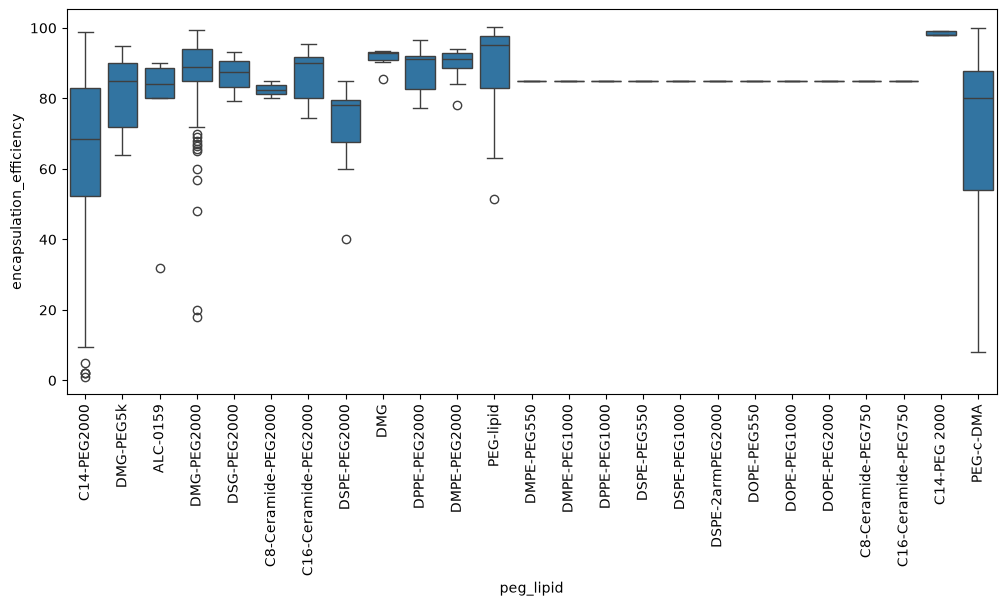

In [56]:
plt.figure(figsize=(12,5))
import seaborn as sns
sns.boxplot(
    data=df_model,
    x="peg_lipid",
    y="encapsulation_efficiency"
)
plt.xticks(rotation=90)
plt.show()

### PEG Lipid - Observations & Cleaning Strategy


**Observations:**
The peg_lipid feature contains a formatting inconsistency (C14-PEG2000 vs. C14-PEG 2000) that artificially splits a single category. After correcting this, the distribution shows 12 well-represented PEG lipids and a long tail of 11 rare variants appearing only 1 or 2 times each.

**Strategy:** Typo Correction & Thresholding

- Merge formatting variations of C14-PEG2000.

- Group all PEG lipids with fewer than 5 instances into an "Other" category.

**Machine Learning Rationale:**
Fixing textual inconsistencies is critical to ensure the model recognizes identical features. Applying the frequency threshold to the remaining tail prevents the curse of dimensionality and stops the model from memorizing single-instance formulations, keeping the feature space dense and generalizable.

In [57]:
# Fix the spacing typo
df_model["peg_lipid"] = df_model["peg_lipid"].replace({"C14-PEG 2000": "C14-PEG2000"})

# Calculate the new frequencies
peg_counts = df_model["peg_lipid"].value_counts()

# Identify categories with fewer than 5 instances
rare_pegs = peg_counts[peg_counts < 5].index

# Create the grouped column
df_model["peg_lipid_grouped"] = df_model["peg_lipid"].replace(rare_pegs, "Other")

In [58]:
# Verify the new distribution
print(df_model["peg_lipid_grouped"].value_counts())

peg_lipid_grouped
C14-PEG2000             264
DMG-PEG2000             117
PEG-lipid                58
PEG-c-DMA                46
DMG-PEG5k                23
DMPE-PEG2000             14
Other                    13
C16-Ceramide-PEG2000     13
DSG-PEG2000               8
DSPE-PEG2000              7
DPPE-PEG2000              7
ALC-0159                  6
DMG                       6
Name: count, dtype: int64


### PEG Lipid - One-Hot Encoding

In [59]:
# Create dummy variables
peg_dummies = pd.get_dummies(
    df_model["peg_lipid_grouped"],
    prefix="peg", 
    dtype=int
)

# Attach to the main DataFrame
df_model = pd.concat([df_model, peg_dummies], axis=1)

# Verify the new columns were added successfully
print(df_model.columns)

Index(['lnp_id', 'ionizable_lipid', 'peg_lipid', 'sterol_lipid',
       'helper_lipid', 'lipid_molar_ratio', 'particle_size_nm_std', 'pdi_std',
       'zeta_potential_mv_std', 'encapsulation_efficiency_percent_std',
       'loading_capacity_std', 'target_type', 'nucleic_acid_sequence',
       'peg_lipid_original', 'ionizable_lipid_original',
       'helper_lipid_original', 'sterol_lipid_original',
       'ionizable_lipid_smiles', 'peg_lipid_smiles', 'sterol_lipid_smiles',
       'helper_lipid_smiles', 'synthesis_info', 'bioactivity_profile',
       'paper_title', 'paper_authors', 'paper_doi', 'paper_journal',
       'paper_year', 'encapsulation_efficiency', 'lipid_molar_ratio_clean',
       'ionizable_ratio', 'helper_ratio', 'sterol_ratio', 'peg_ratio',
       'ratio_sum', 'particle_size_nm', 'ionizable_lipid_grouped',
       'ionizable_4A3-SC8', 'ionizable_A2-Iso5-2DC18', 'ionizable_ALC-0315',
       'ionizable_AX4', 'ionizable_C12-200', 'ionizable_Custom lipid',
       'ionizable_DLi

# Categorical Feature: Target Type


### Target Type - Exploration

In [60]:
df_model["target_type"].value_counts()

target_type
mRNA     456
siRNA     90
ASO       19
DNA       15
empty      2
Name: count, dtype: int64

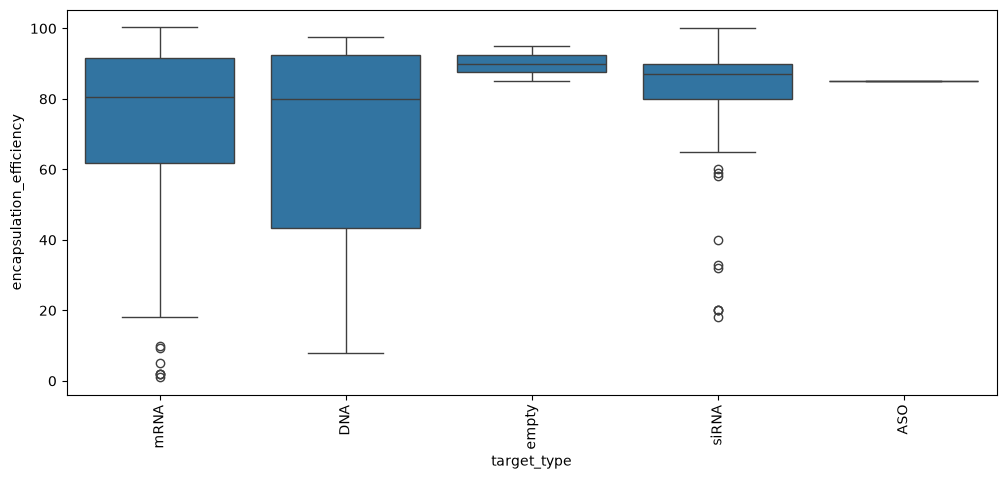

In [61]:
plt.figure(figsize=(12,5))
import seaborn as sns
sns.boxplot(
    data=df_model,
    x="target_type",
    y="encapsulation_efficiency"
)
plt.xticks(rotation=90)
plt.show()

### Target Type - Observations & Cleaning Strategy
**Observations:**
The target_type feature consists of four valid nucleic acid cargos (mRNA, siRNA, ASO, DNA) and 2 instances labeled as empty.

**Strategy:** Row Deletion & Direct Encoding

- Drop the rows where target_type is empty.
- One-hot encode the remaining four categories directly without thresholding.

**Machine Learning & Domain Rationale:**
"Empty" LNPs are experimental controls lacking cargo, making the concept of "encapsulation efficiency" physically irrelevant for them. Removing these 2 outlier rows eliminates noise and preserves the domain integrity of the predictive model. The remaining four categories represent valid nucleic acids and have sufficient frequency to be encoded as independent features.

In [62]:
# Drop the 'empty' control rows
df_model = df_model[df_model["target_type"] != "empty"].copy()

### Target Type - One-Hot Encoding

In [63]:
# Create dummy variables for the valid nucleic acid targets
target_dummies = pd.get_dummies(
    df_model["target_type"],
    prefix="target", 
    dtype=int
)

# Attach to the main DataFrame
df_model = pd.concat([df_model, target_dummies], axis=1)

# Verify
print(df_model["target_type"].value_counts())
print(df_model.columns)

target_type
mRNA     456
siRNA     90
ASO       19
DNA       15
Name: count, dtype: int64
Index(['lnp_id', 'ionizable_lipid', 'peg_lipid', 'sterol_lipid',
       'helper_lipid', 'lipid_molar_ratio', 'particle_size_nm_std', 'pdi_std',
       'zeta_potential_mv_std', 'encapsulation_efficiency_percent_std',
       'loading_capacity_std', 'target_type', 'nucleic_acid_sequence',
       'peg_lipid_original', 'ionizable_lipid_original',
       'helper_lipid_original', 'sterol_lipid_original',
       'ionizable_lipid_smiles', 'peg_lipid_smiles', 'sterol_lipid_smiles',
       'helper_lipid_smiles', 'synthesis_info', 'bioactivity_profile',
       'paper_title', 'paper_authors', 'paper_doi', 'paper_journal',
       'paper_year', 'encapsulation_efficiency', 'lipid_molar_ratio_clean',
       'ionizable_ratio', 'helper_ratio', 'sterol_ratio', 'peg_ratio',
       'ratio_sum', 'particle_size_nm', 'ionizable_lipid_grouped',
       'ionizable_4A3-SC8', 'ionizable_A2-Iso5-2DC18', 'ionizable_ALC-0315',
  

# Final Feature Selection


Combine the cleaned numerical features with the newly generated categorical dummy variables to create the final machine-learning-ready dataset. Drop all original text and intermediate columns.

In [64]:
print(f"Final dataset shape: {df_model.shape}")
df_model.head()

Final dataset shape: (580, 80)


,lnp_id,ionizable_lipid,peg_lipid,sterol_lipid,helper_lipid,lipid_molar_ratio,particle_size_nm_std,pdi_std,zeta_potential_mv_std,encapsulation_efficiency_percent_std,...,peg_DPPE-PEG2000,peg_DSG-PEG2000,peg_DSPE-PEG2000,peg_Other,peg_PEG-c-DMA,peg_PEG-lipid,target_ASO,target_DNA,target_mRNA,target_siRNA
0,466,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,173.6,0.184,NaN,78.45,...,0,0,0,0,0,0,0,0,1,0
1,467,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,182.6,0.209,NaN,88.62,...,0,0,0,0,0,0,0,0,1,0
2,468,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,129.2,0.139,NaN,85.73,...,0,0,0,0,0,0,0,0,1,0
3,469,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,125.4,0.155,NaN,85.71,...,0,0,0,0,0,0,0,0,1,0
4,470,Custom lipid,C14-PEG2000,cholesterol,DSPC,50:1.5:38.5:10,126.6,0.193,NaN,76.7,...,0,0,0,0,0,0,0,0,1,0


In [65]:
# Define the numerical features and target
from typing import Any

numerical_features = [
    "ionizable_ratio", 
    "helper_ratio", 
    "sterol_ratio", 
    "peg_ratio", 
    "particle_size_nm"
]
target = "encapsulation_efficiency"

# Dynamically gather all the dummy column names created
dummy_features = (
    list(ionizable_dummies.columns) +
    list[Any](helper_dummies.columns) +
    list[Any](sterol_dummies.columns) +
    list(peg_dummies.columns) +
    list(target_dummies.columns)
)

# Create the final, clean DataFrame
selected_columns = numerical_features + dummy_features + [target]
df_final_all = df_model[selected_columns].copy()

print(f"Final dataset shape: {df_final_all.shape}")
df_final_all.head(3)

Final dataset shape: (580, 46)


,ionizable_ratio,helper_ratio,sterol_ratio,peg_ratio,particle_size_nm,ionizable_4A3-SC8,ionizable_A2-Iso5-2DC18,ionizable_ALC-0315,ionizable_AX4,ionizable_C12-200,...,peg_DSG-PEG2000,peg_DSPE-PEG2000,peg_Other,peg_PEG-c-DMA,peg_PEG-lipid,target_ASO,target_DNA,target_mRNA,target_siRNA,encapsulation_efficiency
0,50.0,10.0,38.5,1.5,173.6,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,78.45
1,50.0,10.0,38.5,1.5,182.6,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,88.62
2,50.0,10.0,38.5,1.5,129.2,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,85.73


## Feature Exploration & Correlation

**Action:**
Calculate the Pearson correlation matrix for all features and visualize how they interact with both each other and the target variable (`encapsulation_efficiency`). 

**Goal:**
Identify which categorical or numerical features have the strongest positive or negative linear relationships with how well the LNP encapsulates its cargo.

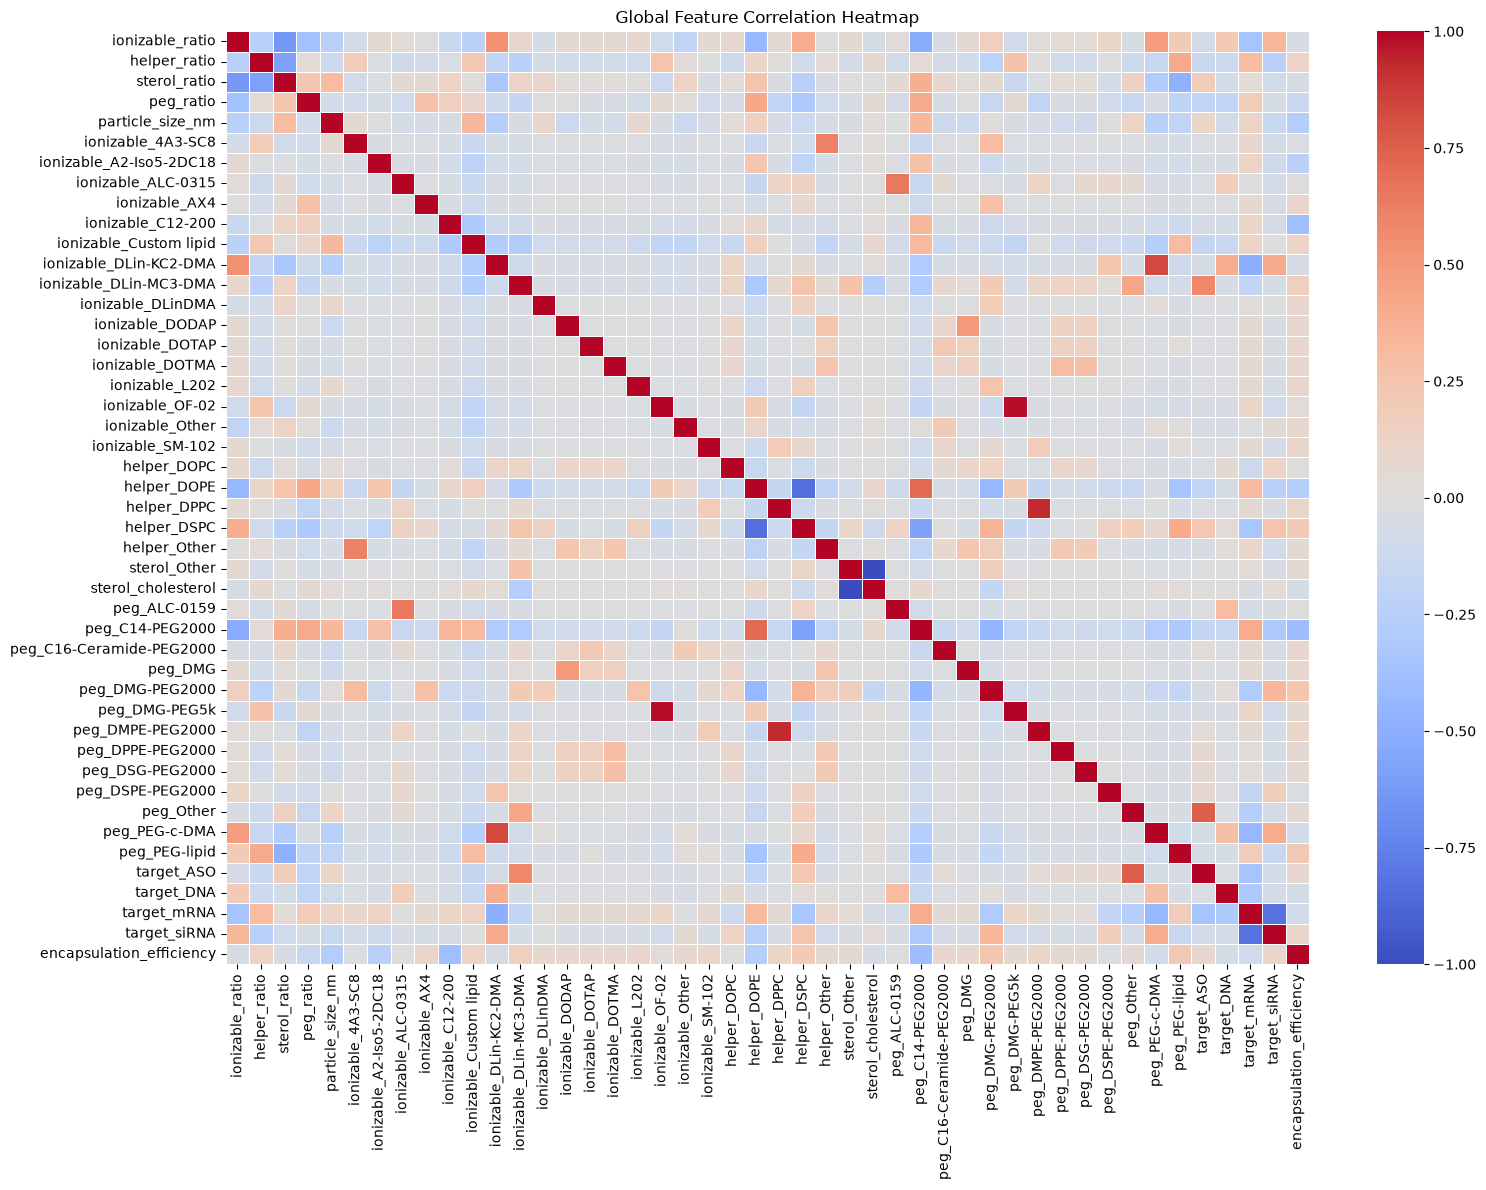

--- Top Positive Correlations with Target ---
peg_DMG-PEG2000           0.236981
peg_PEG-lipid             0.216682
helper_DSPC               0.206176
ionizable_DLin-MC3-DMA    0.156944
helper_ratio              0.126641
ionizable_Custom lipid    0.117771
helper_DPPC               0.106786
Name: encapsulation_efficiency, dtype: float64
\n--- Top Negative Correlations with Target ---
peg_C14-PEG2000           -0.404570
ionizable_C12-200         -0.391287
particle_size_nm          -0.272434
helper_DOPE               -0.258136
ionizable_A2-Iso5-2DC18   -0.234874
peg_ratio                 -0.148236
target_mRNA               -0.095307
peg_PEG-c-DMA             -0.082636
Name: encapsulation_efficiency, dtype: float64


In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation matrix
corr_matrix = df_final_all.corr()

# 2. Plot the Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix, 
    cmap="coolwarm", 
    center=0, 
    annot=False,  # Set to True if you want to see the numbers
    linewidths=0.5
)
plt.title("Global Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# 3. Print the top positive and negative correlations with the Target
print("--- Top Positive Correlations with Target ---")
print(corr_matrix["encapsulation_efficiency"].sort_values(ascending=False).head(8)[1:])
print("\\n--- Top Negative Correlations with Target ---")
print(corr_matrix["encapsulation_efficiency"].sort_values(ascending=True).head(8))

### Fixing the Dummy Variable for Sterol Lipids

**Observation:**
The correlation matrix reveals a perfect inverse correlation between `sterol_cholesterol` and `sterol_Other`. 

**Action:**
Since the `sterol_lipid_grouped` feature was reduced to exactly two mutually exclusive categories, keeping both dummy columns is mathematically redundant. The `sterol_Other` column is dropped. A value of `0` in the remaining `sterol_cholesterol` column implicitly tells the model that the lipid is "Other".

In [67]:
# Drop the redundant 'sterol_Other' column safely from both DataFrames
df_model = df_model.drop(columns=["sterol_Other"], errors="ignore")
df_final_all = df_final_all.drop(columns=["sterol_Other"], errors="ignore")

# Verify it was removed
print("sterol_Other in df_final_all:", "sterol_Other" in df_final_all.columns)

sterol_Other in df_final_all: False


# Save & Export the data

In [68]:
df_final_all.shape
#df_final_all.columns

(580, 45)

In [69]:
from IPython.display import display, Markdown

# 1. Dynamically count features based on column prefixes
num_count = len(numerical_features) # Using the list you defined earlier
ionizable_count = df_final_all.columns.str.startswith("ionizable_").sum()-1
helper_count = df_final_all.columns.str.startswith("helper_").sum()-1
sterol_count = df_final_all.columns.str.startswith("sterol_").sum()-1
peg_count = df_final_all.columns.str.startswith("peg_").sum()-1
target_count = df_final_all.columns.str.startswith("target_").sum()

# 2. Build the summary DataFrame
summary_df = pd.DataFrame({
    "Feature Category": ["Numerical", "Ionizable Lipid", "Helper Lipid", "Sterol Lipid", "PEG Lipid", "Target Type"],
    "Count": [num_count, ionizable_count, helper_count, sterol_count, peg_count, target_count],
    "Data Type": ["Continuous", "Binary (0/1)", "Binary (0/1)", "Binary (0/1)", "Binary (0/1)", "Binary (0/1)"]
})

# 3. Display the results cleanly
total_features = summary_df['Count'].sum()
display(Markdown(f"### Final Dataset Summary"))
display(Markdown(f"The final modeling dataset contains **{total_features + 1} total columns**: 1 target variable (`encapsulation_efficiency`) and {total_features} predictive features."))
display(summary_df)

### Final Dataset Summary

The final modeling dataset contains **45 total columns**: 1 target variable (`encapsulation_efficiency`) and 44 predictive features.

,Feature Category,Count,Data Type
0,Numerical,5,Continuous
1,Ionizable Lipid,16,Binary (0/1)
2,Helper Lipid,5,Binary (0/1)
3,Sterol Lipid,1,Binary (0/1)
4,PEG Lipid,13,Binary (0/1)
5,Target Type,4,Binary (0/1)


In [70]:
# Save the final dataset for Model 3
df_final_all.to_csv("../data/processed/df_final_all_features.csv", index=False)
df_model.to_csv("../data/processed/df_model_all_features.csv", index=False)
print("Dataset exported successfully!")

Dataset exported successfully!
